In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_scoreS

ImportError: cannot import name 'f1_scoreS' from 'sklearn.metrics' (d:\AI-ML\.venv\Lib\site-packages\sklearn\metrics\__init__.py)

In [47]:
#Loading Dataset
df = pd.read_csv("datasets/DP_LMS_AI_Internship_Assessment_Dataset.csv")

In [48]:
#Display the first 10 records 
df.head(10)

,student_id,student_name,class,program,attendance_pct,assignment_score,exam_score,study_hours_per_day,lms_logins_per_week,course_completion_pct,quiz_average_pct,assignment_submission_rate_pct,days_since_last_login,fees_due,teacher_interactions_per_month,risk_level
0,STU1001,Student_1,Grade 11,Computer Science,80.8,81.3,90.1,1.6,3.7,61.5,56.1,38.5,1,No,2.5,Low
1,STU1002,Student_2,Grade 12,Science,100.0,66.3,94.5,3.4,2.4,99.8,71.3,75.1,2,No,5.6,Low
2,STU1003,Student_3,Grade 9,Science,89.3,81.5,68.5,2.1,6.0,64.3,84.6,80.6,11,No,5.8,Medium
3,STU1004,Student_4,Grade 11,Humanities,67.9,89.7,55.2,2.8,6.3,79.7,72.4,93.3,4,No,2.9,Medium
4,STU1005,Student_5,Grade 11,Computer Science,63.4,85.1,75.8,3.6,0.5,74.8,43.2,90.5,7,No,1.2,Low
5,STU1006,Student_6,Grade 12,Science,82.9,80.1,56.5,2.8,2.3,29.4,56.4,88.5,5,No,0.0,Low
6,STU1007,Student_7,Grade 9,Humanities,57.5,89.1,100.0,2.1,1.2,87.4,68.7,63.6,0,Yes,0.4,Low
7,STU1008,Student_8,Grade 9,Computer Science,100.0,90.7,70.3,2.6,2.9,76.3,68.7,43.7,5,No,0.5,Medium
8,STU1009,Student_9,Grade 11,Humanities,92.5,94.1,61.8,2.7,4.0,82.2,100.0,70.9,1,No,5.5,Low
9,STU1010,Student_10,Grade 10,Management,69.4,82.4,71.1,2.2,1.3,NaN,46.4,96.0,4,No,3.2,Low


In [49]:
#show the number of rows and columns.
df.shape

(508, 16)

In [50]:
#Check missing values and duplicate records
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts)
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Missing values per column:
 student_id                         0
student_name                       0
class                              0
program                            0
attendance_pct                    15
assignment_score                  12
exam_score                         0
study_hours_per_day               11
lms_logins_per_week                0
course_completion_pct             11
quiz_average_pct                   0
assignment_submission_rate_pct     0
days_since_last_login              0
fees_due                           0
teacher_interactions_per_month     0
risk_level                         0
dtype: int64
Total duplicate rows: 8


In [51]:
#cleaning them appropriately by placing median in missing colums.
cols = ['attendance_pct', 'assignment_score',
        'study_hours_per_day', 'course_completion_pct']
df[cols] = df[cols].fillna(df[cols].median())
print(df.isnull().sum())

student_id                        0
student_name                      0
class                             0
program                           0
attendance_pct                    0
assignment_score                  0
exam_score                        0
study_hours_per_day               0
lms_logins_per_week               0
course_completion_pct             0
quiz_average_pct                  0
assignment_submission_rate_pct    0
days_since_last_login             0
fees_due                          0
teacher_interactions_per_month    0
risk_level                        0
dtype: int64


In [52]:
#Calculate the average attendance, exam score, assignment score, and course completion.
print("Average Attendance:", df['attendance_pct'].mean())
print("Average Exam Score:", df['exam_score'].mean())
print("Average Assignment Score:", df['assignment_score'].mean())
print("Average Course Completion:", df['course_completion_pct'].mean())

Average Attendance: 75.86692913385825
Average Exam Score: 69.1984251968504
Average Assignment Score: 72.80236220472442
Average Course Completion: 71.46673228346457


In [53]:
#Students whose attendance is below 60%
low_attendance = df[df['attendance_pct'] < 60]
print(low_attendance[['student_id', 'student_name', 'attendance_pct']])

    student_id student_name  attendance_pct
6      STU1007    Student_7            57.5
10     STU1011   Student_11            52.0
14     STU1015   Student_15            53.7
26     STU1027   Student_27            54.5
43     STU1044   Student_44            51.4
44     STU1045   Student_45            59.4
45     STU1046   Student_46            47.5
51     STU1052   Student_52            56.7
52     STU1053   Student_53            52.2
56     STU1057   Student_57            47.1
58     STU1059   Student_59            57.7
73     STU1074   Student_74            59.2
85     STU1086   Student_86            43.8
86     STU1087   Student_87            54.8
96     STU1097   Student_97            53.5
99     STU1100  Student_100            56.1
113    STU1114  Student_114            56.6
116    STU1117  Student_117            56.4
134    STU1135  Student_135            52.6
139    STU1140  Student_140            50.7
140    STU1141  Student_141            53.2
145    STU1146  Student_146     

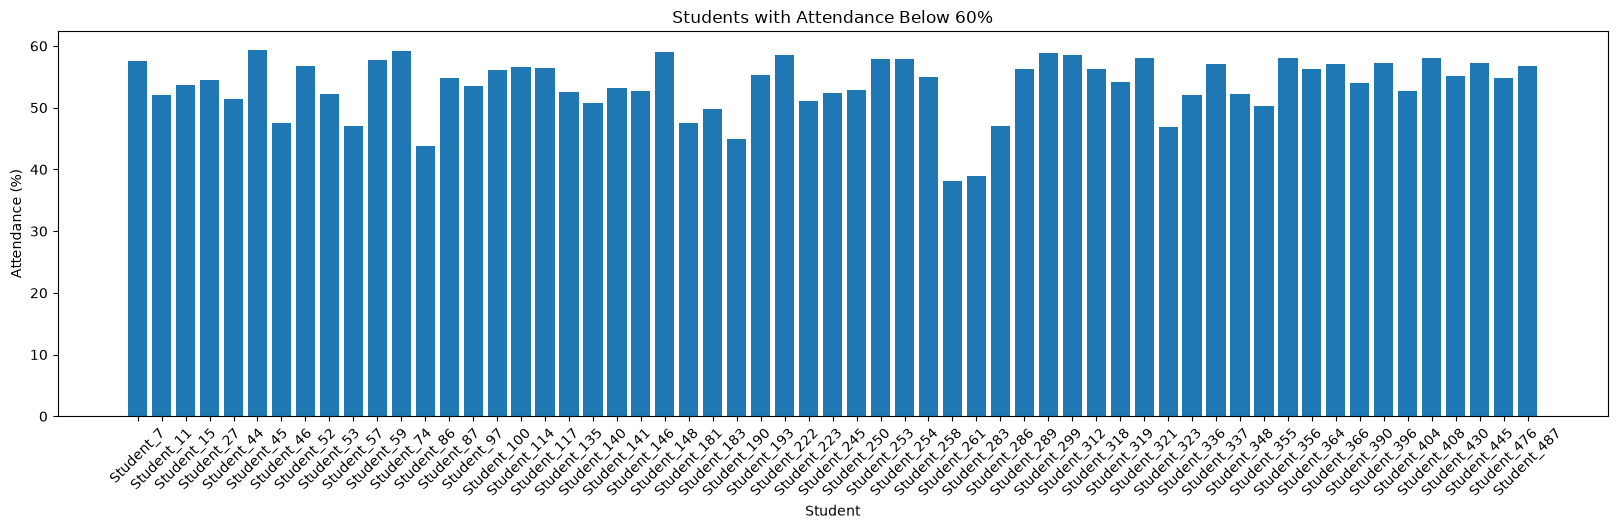

In [54]:
#create at least 2 useful charts.
#1. Studens with Attendance Below 60%
plt.figure(figsize=(20, 5))
plt.bar(low_attendance['student_name'],
        low_attendance['attendance_pct'])
plt.xlabel('Student')
plt.ylabel('Attendance (%)')
plt.title('Students with Attendance Below 60%')
plt.xticks(rotation=45)
plt.show()

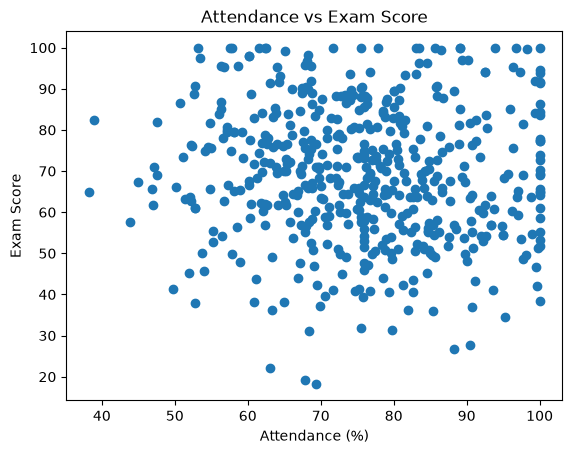

In [55]:
#2. Attendance vs Exam Score
plt.scatter(df['attendance_pct'], df['exam_score'])
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')
plt.title('Attendance vs Exam Score')
plt.show()

In [73]:
#feature and target selection
X = df[['attendance_pct',
        'exam_score',
        'assignment_score',
        'lms_logins_per_week',
        'course_completion_pct']]

y = df['risk_level']

#spliting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#training Model with adabooster
weak_learner = DecisionTreeClassifier(
    max_depth=2,     
    random_state=42
)
model = AdaBoostClassifier(
    estimator = weak_learner,
    n_estimators = 50,
    random_state = 42,
    learning_rate = 0.1
)
model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[object](3,)","['High','Low','Medium']"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...ndom_state=42)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.28,0.33,0.37,...,0.5 ,0.48,0.5 ]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[0.16,0.14,0.12,...,0.07,0.08,0.07]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](5,)","[0.4 ,0.38,0.04,0.05,0.13]"


In [74]:
prediction = model.predict(X_test)
prediction

array(['Low', 'Low', 'Medium', 'Medium', 'Medium', 'Low', 'Medium', 'Low',
       'Low', 'Medium', 'Medium', 'Low', 'Medium', 'Low', 'Low', 'Low',
       'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Low',
       'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Low',
       'Low', 'Low', 'Medium', 'Medium', 'High', 'Low', 'Medium', 'Low',
       'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Medium',
       'Medium', 'Low', 'Low', 'Low', 'Low', 'Medium', 'Medium', 'Low',
       'Low', 'Low', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Medium',
       'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low',
       'Low', 'Low', 'Low', 'Medium', 'Low', 'Medium', 'Low', 'Low',
       'Medium', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Low', 'Low',
       'Medium', 'Low', 'Medium', 'Low', 'Low', 'Low', 'Medium', 'Low',
       'Medium', 'Low'], dtype=object)

In [76]:
#evaluate it using accuracy and F1-score.
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("F1-score:", f1)

Accuracy: 0.6568627450980392
F1-score: 0.6414054276940439


In [77]:
#students with attendance below 60%.
low_attendance = df[df['attendance_pct'] < 60]
print(low_attendance[['student_id', 'student_name', 'attendance_pct']])

    student_id student_name  attendance_pct
6      STU1007    Student_7            57.5
10     STU1011   Student_11            52.0
14     STU1015   Student_15            53.7
26     STU1027   Student_27            54.5
43     STU1044   Student_44            51.4
44     STU1045   Student_45            59.4
45     STU1046   Student_46            47.5
51     STU1052   Student_52            56.7
52     STU1053   Student_53            52.2
56     STU1057   Student_57            47.1
58     STU1059   Student_59            57.7
73     STU1074   Student_74            59.2
85     STU1086   Student_86            43.8
86     STU1087   Student_87            54.8
96     STU1097   Student_97            53.5
99     STU1100  Student_100            56.1
113    STU1114  Student_114            56.6
116    STU1117  Student_117            56.4
134    STU1135  Student_135            52.6
139    STU1140  Student_140            50.7
140    STU1141  Student_141            53.2
145    STU1146  Student_146     

In [80]:
#average attendance by class.
average_attendance = df.groupby("class", as_index=False)["attendance_pct"].mean()
print(average_attendance)

      class  attendance_pct
0  Grade 10       76.248182
1  Grade 11       74.983200
2  Grade 12       75.488667
3   Grade 9       76.885366


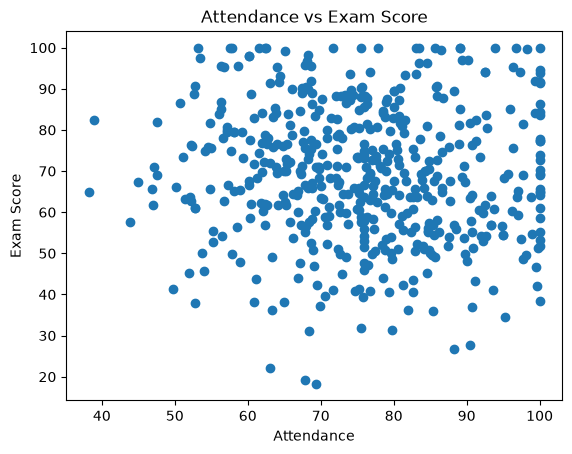

In [82]:
#chart comparing Attendance vs Exam Score.
plt.scatter(df["attendance_pct"], df["exam_score"])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")
plt.show()

In [87]:
#attendance_status column: Good (80%+), Average (60–79%), Low (below 60%).
df["attendance_status"] = np.select(
    [
        df["attendance_pct"] >= 80,
        df["attendance_pct"] >= 60
    ],
    [
        "Good",
        "Average"
    ],
    default="Low"
)

print(df[["attendance_pct", "attendance_status"]])

     attendance_pct attendance_status
0              80.8              Good
1             100.0              Good
2              89.3              Good
3              67.9           Average
4              63.4           Average
..              ...               ...
503            92.5              Good
504            80.0              Good
505            60.2           Average
506            52.8               Low
507            95.0              Good

[508 rows x 2 columns]


In [90]:
#total students, average attendance, average exam score, and average course completion.
print("Total Students:", df.shape[0])
print("Average Attendance:", df["attendance_pct"].mean())
print("Average Exam Score:", df["exam_score"].mean())
print("Average Course Completion:", df["course_completion_pct"].mean())

Total Students: 508
Average Attendance: 75.86692913385825
Average Exam Score: 69.1984251968504
Average Course Completion: 71.46673228346457


In [92]:
#the number of Low, Medium, and High-risk students.
print("Low-risk students:", (df["risk_level"] == "Low").sum())
print("Medium-risk students:", (df["risk_level"] == "Medium").sum())
print("High-risk students:", (df["risk_level"] == "High").sum())

Low-risk students: 319
Medium-risk students: 185
High-risk students: 4


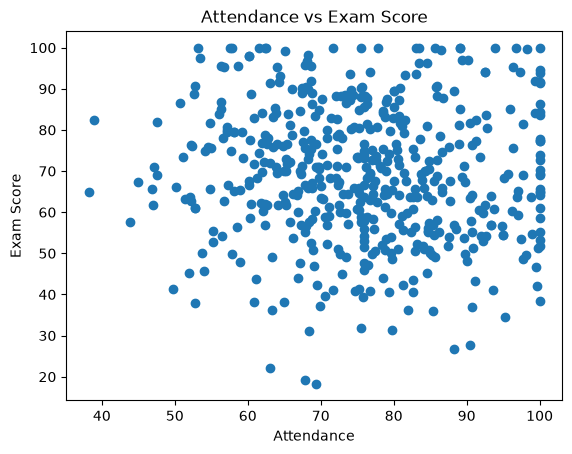

In [94]:
#Attendance vs Exam Score
plt.scatter(df["attendance_pct"], df["exam_score"])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")
plt.show()

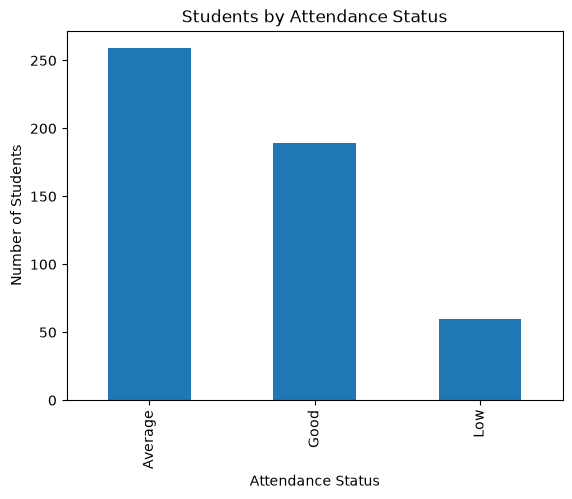

In [95]:
#Studens by Attendance Status
df["attendance_status"].value_counts().plot(kind="bar")
plt.xlabel("Attendance Status")
plt.ylabel("Number of Students")
plt.title("Students by Attendance Status")
plt.show()

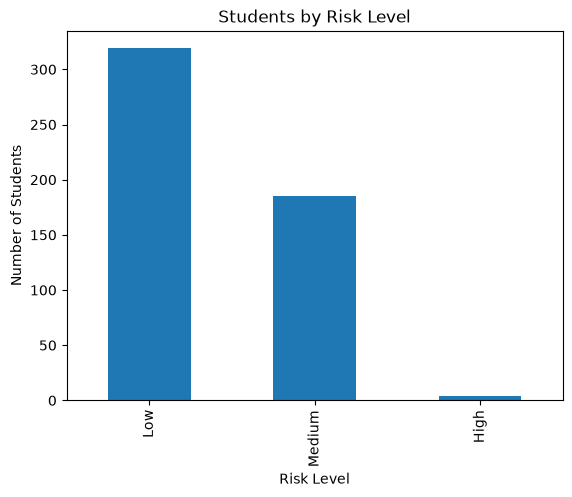

In [98]:
df["risk_level"].value_counts().plot(kind="bar")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.title("Students by Risk Level")
plt.show()

NameError: name 'dashboard' is not defined